In [ ]:
#Dzisiaj sprawdzę jak myśli model. Skorzystam z biblioteki SHAP, który pozwala matematycznie obliczyć ile 
#dany bit wpływa na ostateczny wynik LogP.

# SHAP #
#Bibliotek SHAP (SHapley Additive exPlenations), służy do wyjaśniania sztucznej inteligencji. Jeśli przekształcimy
#cząsteczke na wektor bitów, i obliczymy jego właściwości (w naszym przypadku LogP), to SHAP pokazuję nam 
#jaki wkład każdy bit miał na tą otrzymaną wartość. Shap nie zmienia sposobu w jaki model się uczy- zmienia
#się tylko i wyłącznie sposób w jaki interpretujemy wynik. Można powiedzięć, że bada to w taki sposób -
#co by się stało jakby usunąć dany bit (bit odpowiada fragmentowi cząsteczki) i jak wpłynie to na LogP.
#Jeśli LogP drastycznie spada to znaczy że był to kluczowy bit (fragment) cząsteczki - miał duży wkład.
#Model SHAP zachowuję spójność i dokładność lokalną to znaczy że suma wszystkich wkładów SHAP plus wartość bazowa
#przewidywana przez model, zawsze daje taki sam wynik, który model zwrócił.

# NUMPY #
#NumPy (Numerical python) jest to podstawowa biblioteka języka python służąca do zaawansowanych obliczeń 
#naukowych i matematycznych. Jej kluczowym elementem jest ndarrey (N(np.1,2,3...)wymiarowa tablica, która
#pozwala na przechowywanie dużych zbiorów danych w pamięci w sposób zoptymalizowany.
#Operacje na NumPy są wykonywane w zoptymaliozwanym kodzie języka C - wktoryzacja, co czyni je wielkrotnie szybszymi
#niż standartowe pętle Python.

#Ważne: Wartości SHAP dla fingerprintów Morgana (bitów) są trudne do interpretacji bezpośredniej,
#ponieważ jeden bit może reprezentować różne, nakładające się na siebie fragmenty cząsteczki
#(tzw. kolizje bitów).
#Interpretacja zawsze powinna być wspierana wizualizacją cząsteczki!



Pobieranie danych...
Trenowanie modelu...
Analizowanie...
Generowanie wykresu


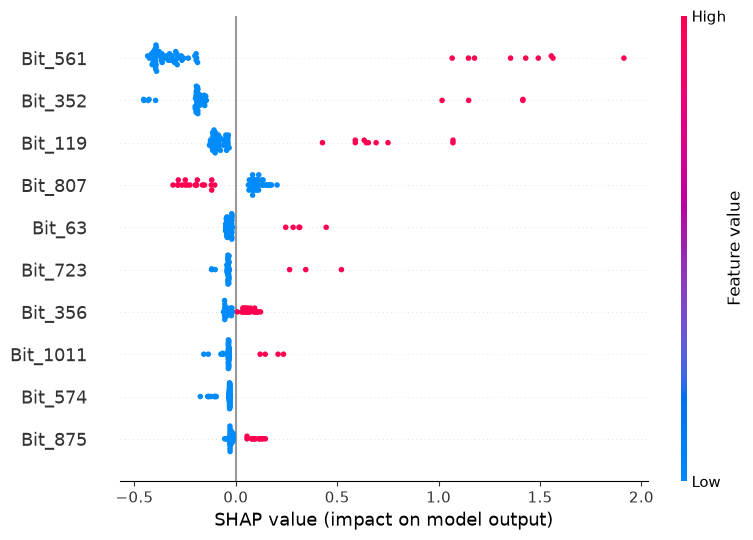

In [2]:
import pandas as pd
import shap #Główna biblioteka do wyjaśniania decyzji modeli sztucznej inteligencji
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdFingerprintGenerator
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import numpy as np #numpy to biblioteka do zaawanosowanych obliczeń macierzowych (SHAP je wymaga).

print("Pobieranie danych...")
url ="https://raw.githubusercontent.com/dataprofessor/data/master/delaney.csv"
baza_danych=pd.read_csv(url)
smiles_list= baza_danych['SMILES'].head(300).tolist() #Pobieram plik csv z przygotowanego pliku w chmurze, wyciągam 300 wzorów chemicznych (SMILES) i zmieniamy na liste. 

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024) #Tworzę generator który patrzy na cząsteczke promieniem 2 wiązań i zmienia to w wektor 1024 bitów
X = [] #Pusta lista
Y = [] #Pusta lista
#PĘTLA - jęsli rdkit dobrze zmieni smiles na obiekt mol, to oblicza dla wszystkich cząstek LogP.
for sml in smiles_list:
    mol=Chem.MolFromSmiles(sml) #Znienia smiles na obiekt molekuły
    if mol is not None: #Sprawdzam dane czy nie ma błędu
        fp=morgan_gen.GetFingerprint(mol) # Generuję Fingerprinty dla mol
        X.append(list(fp)) #Dodaję fingerprinty do pustej listy X (dane wejściowe dla modelu)
        Y.append(Descriptors.MolLogP(mol)) #Oblicza LogP i zapisuje to w Y (wartość która chcemy przewidzieć)

X_trening, X_test, Y_trening, Y_test = train_test_split( #Moge również napisac tu kot, pies, chomik, osa = train_test_split(...)
    X , #Do X dodaliśmy dane wejściowe (fingerprinty)
    Y, #Do Y dodaliśmy obliczone LogP dla molekuł
    test_size=0.2, #20%-test 80%-nauka
    random_state=42 #ziarno losowości
    )

print("Trenowanie modelu...")
model = RandomForestRegressor(random_state=42) 
model.fit(X_trening, Y_trening) #Inicjalizuję las losowy i zmuszam go do nauki (patrz X_trening i spróbuj trafić w Y_trening)

print("Analizowanie...")
explainer= shap.TreeExplainer(model) #Specjalna metoda SHAP stowrzona dla modeli "drzewiastych"
X_test_array = np.array(X_test) #tworzy macierze z listy X_test, ponieważ tylko numpy pozwala komputerowi błyskawicznie obliczać tysięcy liczb naraz

shap_values= explainer.shap_values(X_test_array)#Tutaj obliczam wartości SHAP, które mówią o tym ile każdy bit zmienił LogP, w góre i w dół względem średniej

print("Generowanie wykresu")
#GENEROWANIE WYKRESU
shap.summary_plot( 
    shap_values, #Wartości SHAP
    X_test_array, #Dodaję macierzę
    feature_names=[f"Bit_{i}" for i in range(1024)], #Tworzę listę nazw dla 1024 kolumn
    max_display=10) #Ograniczenie do  10 najważniejszych  bitów

        

In [ ]:
#INTERPRETACJA WYNIKÓW
# 1. 1 kropka = 1 cząsteczka (a dokładniej jej fragment).

# 2. kolor czerwony = fragment (bit) JEST w cząsteczce.

# 3. kolor niebieski = fragment (bit) NIE JEST w cząsteczce.

# 4. przesunięcie w prawo >0 dodaje punkty do LogP (cząsteczka jest bardziej hydrofobowa).

# 5. przesunięcie w lewo <0 odejmuję punkty od LogP (cząsteczka jest bardziej hydrofilowa).

#Na samej górze są bity (fragmenty) które najmocniej zmieniają LogP, i model szuka ich w pierwszej kolejności.
#Spójrzmy na bit_561 widzimy czerwone kropki które są mocno po prawej stronie (bity obecne).
#Jeśli model widzi w cząstecę strukturę ukrytą pod bit_561 natychmiast dodaje do wyniku LogP nawet 1,5-2 jednostek.
#Natomiast brak bitów niebieskie kropki ciągna wynik w lewą stronę. 
#Możemy wnioskować że pod tym bitem kryje się mocno hydrofobowy fragment.

#Zwróćmy uwagę na bit_807.
#Czerwone kropki są po lewej stronie, co oznacza że jeśli ten bit (fragment) obecny jest w cząsteczce
#mocno zaniża LogP w stronę bardziej rozpuszczalnych w wodzie związków.
#Brak tego fragmentu powoduję że cząsteczka jest z "automatu" bardziej hydrofobowa.
#Zdecydowanie pod bitem_807 kryję się jakaś polarna grupa funkcyjna

#WNIOSKI

# 1.Model nauczył się przewidywać LogP przede wszystkim poprzez sumowanie fragmentów hydrofobowych (lipofilowych).
#    Algorytm skupia się na wyszukiwaniu struktur, które zmniejszają rozpuszczalność w wodzie.
#    Jeśli je znajdzie, drastycznie podbija wynik LogP w górę.

# 2.Bit_807 reprezentuję silnie polarną grupę funkcyjną. Model traktuję go jako twardą regułę która obniża LogP
#    Jak tylko wykryję ten fragment od rauz ciągnie wynik w strone lepszej rozpuszczalności w wodzie.

# 3.Dla tego zestawu danych zasady chemiczne okazały się dla modelu bardzo proste i addytywne (sumują się).
#    Model nie wnika mocno w skomplikowane oddziaływania przestrzenne – działa raczej jak prosta waga:
#    znalazłem Bit 561, dodaję +1.5 do LogP; znalazłem Bit 807, odejmuję -1.0 od LogP.

# 4.Im patrzymy "niżej" wykresu tym kropki zbliżają się wokół pinowej osi 0.
#    Mówi nam to,że górne bity maja istotny wpływ na rozpuszczalność

#Dla siebie chce wspomnieć o takim jednym problemie. Tutaj obliczaliśmy rozpuszczalność (LogP), więc można zaniedbać
#wpływ występowania enancjomerów (moment diplowy ten sam wiec logP to samo) i diastereoizomerów (moment dipolowy
#różni sie, lecz nieznacznie) na wynik. W przypadku badania załóżmy toksyczności już wystepowanie tych
#struktur jest kluczowe. Musze pamiętać, że orientacja geometryczna tych cząsteczek jest bardzo ważna.
#Dane które obliczy mi model nie zawsze da nam wyniki które realnie przelożą się na występowane w naturze związki.
#Model jest ślepy na rzeczy które mu nie pokaże.

Szukanie cząsteczek...
Znaleziono bity: {561, 807}
Generowanie rysunku...


[01:12:57] DEPRECATION WARNING: please use MorganGenerator
[01:12:57] DEPRECATION WARNING: please use MorganGenerator
[01:12:57] DEPRECATION WARNING: please use MorganGenerator
[01:12:57] DEPRECATION WARNING: please use MorganGenerator
[01:12:57] DEPRECATION WARNING: please use MorganGenerator
[01:12:57] DEPRECATION WARNING: please use MorganGenerator
[01:12:57] DEPRECATION WARNING: please use MorganGenerator
[01:12:57] DEPRECATION WARNING: please use MorganGenerator
[01:12:57] DEPRECATION WARNING: please use MorganGenerator


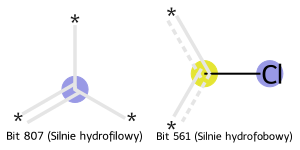

In [10]:
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import Draw

# Lista bitów do wizualizacji
szukane_bity = [561, 807]
znalezione_przyklady = []
znalezione_id = set()

print("Szukanie cząsteczek...")

for sml in smiles_list:
    mol = Chem.MolFromSmiles(sml)
    if mol is not None:
        info = {}
        # Obliczamy fingerprint i zapisujemy informacje o bitach
        fp = rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024, bitInfo=info)
        
        for bit in szukane_bity:
            if bit in info and bit not in znalezione_id:
                # Zapisujemy cząsteczkę, numer bitu i słownik z info o bitach
                znalezione_przyklady.append((mol, bit, info))
                znalezione_id.add(bit)
        
        if len(znalezione_id) == len(szukane_bity):
            break

print(f"Znaleziono bity: {znalezione_id}")
print("Generowanie rysunku...")

opisy = []
for item in znalezione_przyklady:
    bit = item[1]
    if bit == 561:
        opisy.append("Bit 561 (Silnie hydrofobowy)")
    elif bit == 807:
        opisy.append("Bit 807 (Silnie hydrofilowy)")

# Rysowanie - upewnij się, że masz wyświetlacz w notatniku
img = Draw.DrawMorganBits(znalezione_przyklady, molsPerRow=2, legends=opisy, useSVG=True)
display(img)

In [13]:
#Cos mi sie tu nie zgadza ale wroce do tego bo chce mi sie spac. Ten bit 807 tak no średnio.
mol_807 = None
for mol, bit, info in znalezione_przyklady:
    if bit == 807:
        mol_807 = mol
        # info[bit] to lista krotek: (atomIdx, radius)
        atom_idx = info[bit][0][0]
        atom = mol.GetAtomWithIdx(atom_idx)
        print(f"Centrum Bitu 807 to atom: {atom.GetSymbol()}")
        print(f"Liczba sąsiadów tego atomu: {len(atom.GetNeighbors())}")
        for neighbor in atom.GetNeighbors():
            print(f" - Sąsiad: {neighbor.GetSymbol()}")
        break

Centrum Bitu 807 to atom: C
Liczba sąsiadów tego atomu: 3
 - Sąsiad: Cl
 - Sąsiad: C
 - Sąsiad: Cl
SMILES: ClC(=C)Cl | Centrum: C, Sąsiedzi: ['Cl', 'C', 'Cl']


[01:30:14] DEPRECATION WARNING: please use MorganGenerator
[01:30:14] DEPRECATION WARNING: please use MorganGenerator
[01:30:14] DEPRECATION WARNING: please use MorganGenerator
[01:30:14] DEPRECATION WARNING: please use MorganGenerator
[01:30:14] DEPRECATION WARNING: please use MorganGenerator
[01:30:14] DEPRECATION WARNING: please use MorganGenerator
[01:30:14] DEPRECATION WARNING: please use MorganGenerator


In [ ]:
#DENERWUJE SIE ALE CHYBA PO PROSTU BIT 807 OZNACZA SRODOWISKO KTORE MA TAKI SAM WPLYW NIE WIEM ZRObIE TO JUTRO